/home/nafim/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 3050
Data loaded.
TCGA shape: (839, 24)
CGGA shape: (286, 24)
After first split (80% train / 20% test):
  Intermediate train size: 671
  Test size: 168
  Train class distribution:
Grade
0    389
1    282
Name: count, dtype: int64

After inner split (80% of train / 20% of train):
  Final train size: 536
  Validation size: 135
  Final train class distribution (before balancing):
Grade
0    311
1    225
Name: count, dtype: int64

Total patients accounted for: 839 (should equal 839)
Validation, test, and CGGA graphs built.
Validation graph: 135 patients, 20 genes, 309 edges
Test graph: 168 patients, 20 genes, 401 edges
CGGA graph: 286 patients, 20 genes, 582 edges

NO BALANCING
Performing grid search for No Balancing...
  Trial 1/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001}
    Validation AUC: 0.9071
  Trial 2/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0005}


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 328.17it/s]


CTGAN-balanced training set created.
Grade
0    311
1    311
Name: count, dtype: int64
Performing grid search for CTGAN...
  Trial 1/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001}
    Validation AUC: 0.9215
  Trial 2/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0005}
    Validation AUC: 0.9103
  Trial 3/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.005, 'weight_decay': 0.0001}
    Validation AUC: 0.9298
  Trial 4/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.005, 'weight_decay': 0.0005}
    Validation AUC: 0.9294
  Trial 5/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001}
    Validation AUC: 0.9013
  Trial 6/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0005}
    Validation AUC: 0.8034
  Trial 7/72: {'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.5, 'lr': 0.005, 'weight_decay': 0.0001}
 

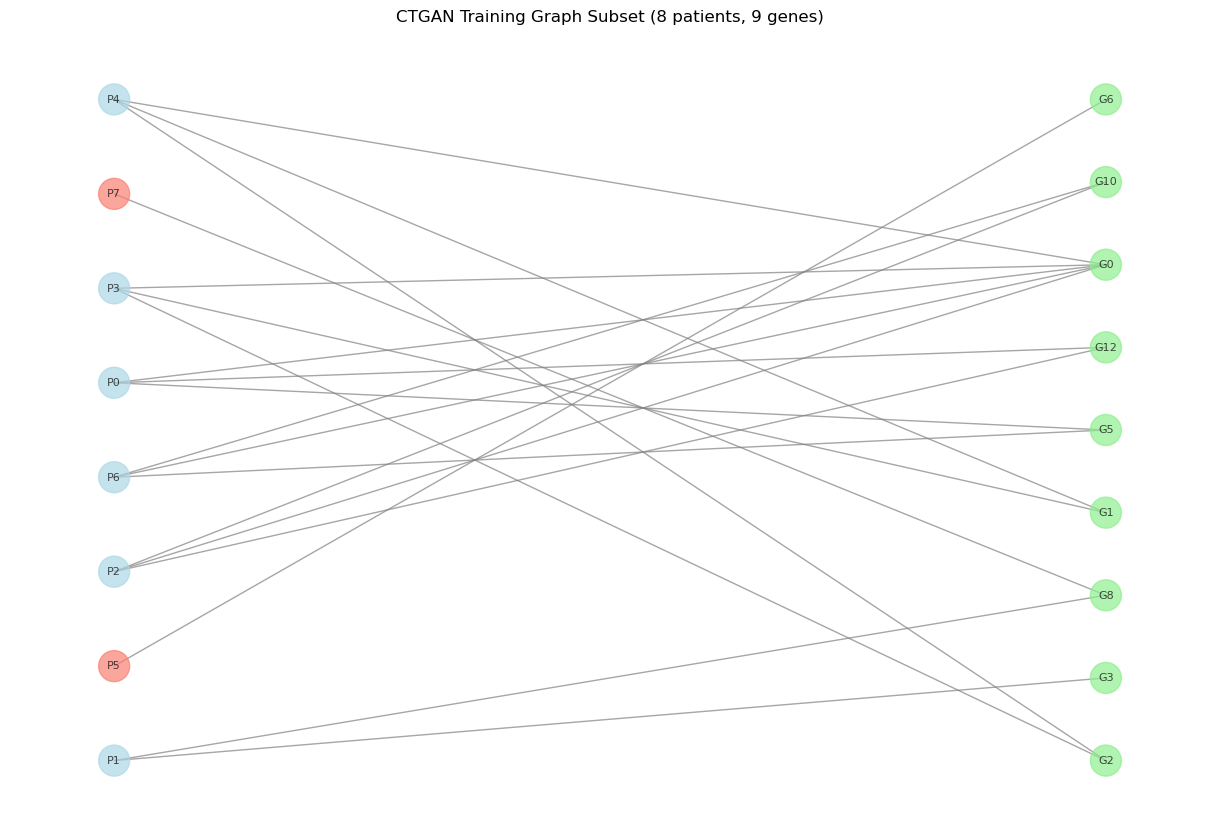

Graph subset contains:
  - 8 patient nodes
  - 9 gene nodes
  - 19 mutation edges
Patient grades in subset: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1)]

=== Summary Table ===
      Method   Dataset  accuracy      auc  precision   recall       f1
No Balancing TCGA Test  0.839286 0.918513   0.765432 0.885714 0.821192
No Balancing      CGGA  0.646853 0.771153   0.502959 0.833333 0.627306
       SMOTE TCGA Test  0.857143 0.917055   0.780488 0.914286 0.842105
       SMOTE      CGGA  0.597902 0.747123   0.464481 0.833333 0.596491
       CTGAN TCGA Test  0.726190 0.904227   0.607143 0.971429 0.747253
       CTGAN      CGGA  0.447552 0.764759   0.391473 0.990196 0.561111


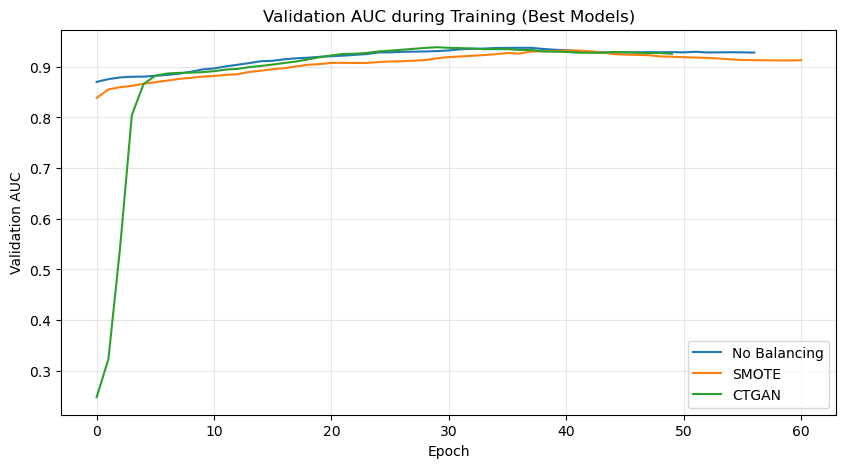

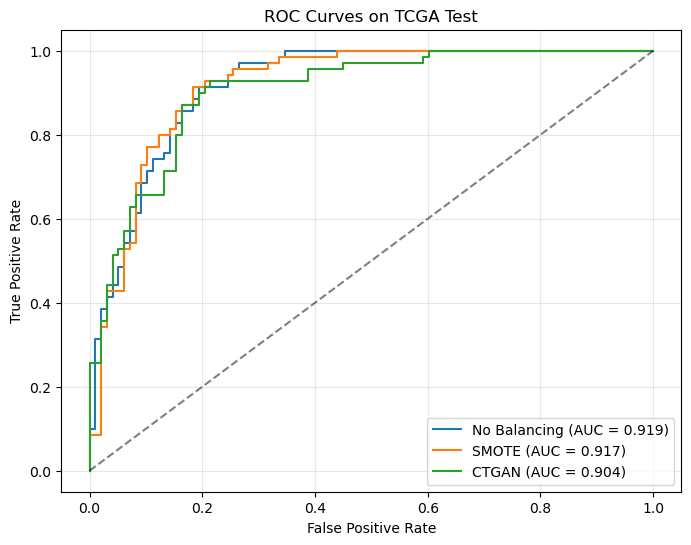

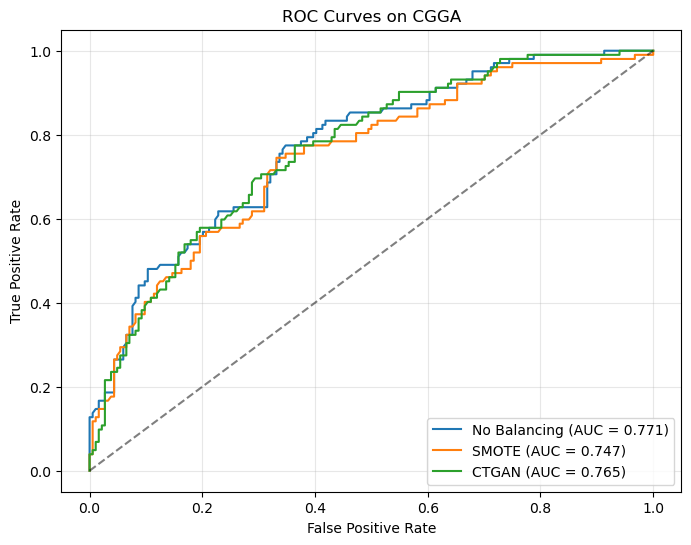

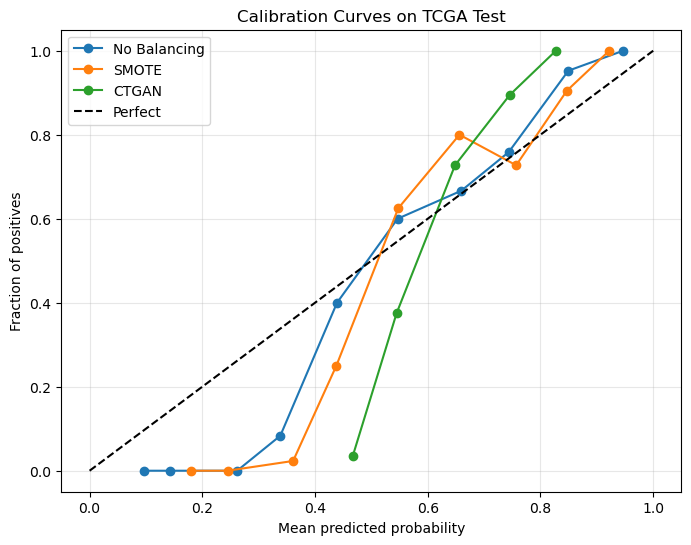

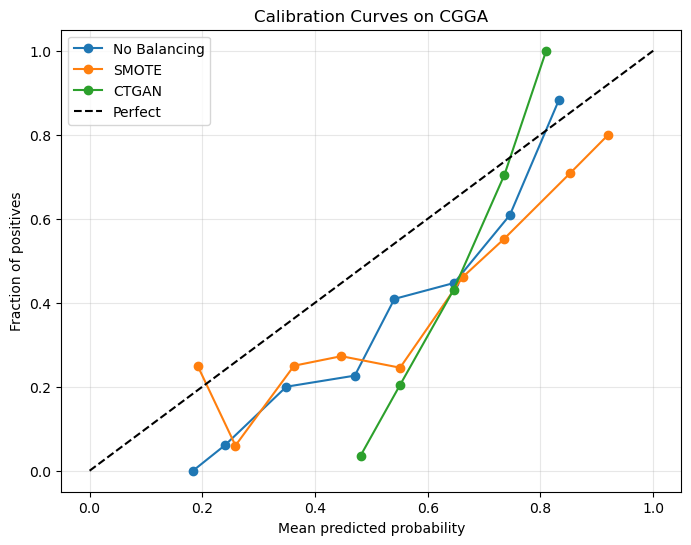

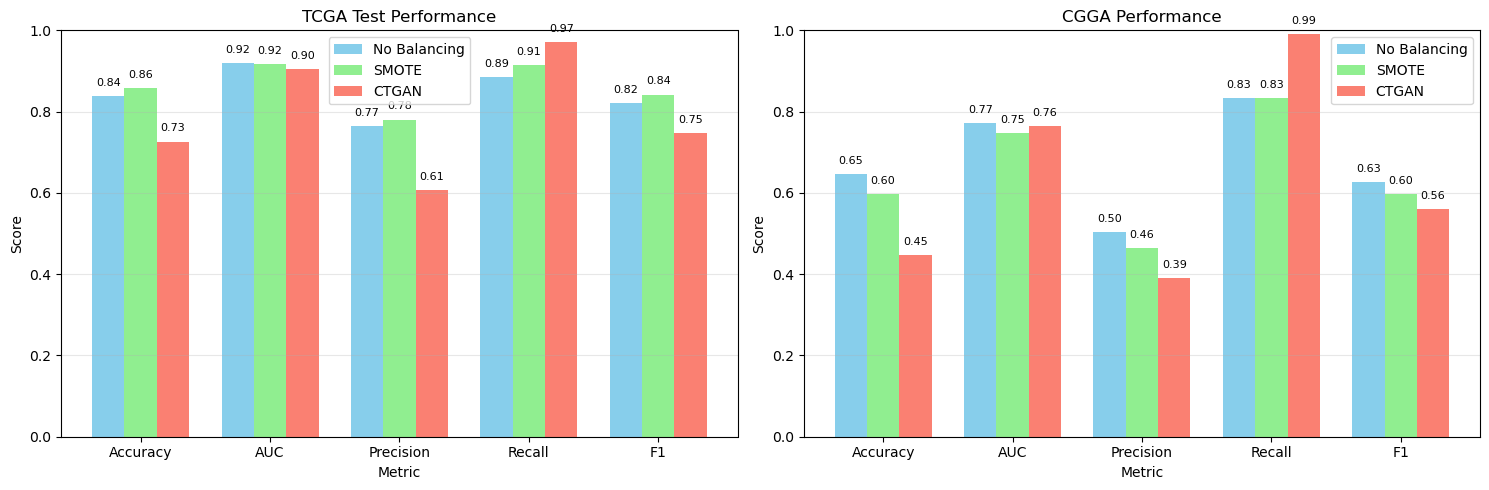

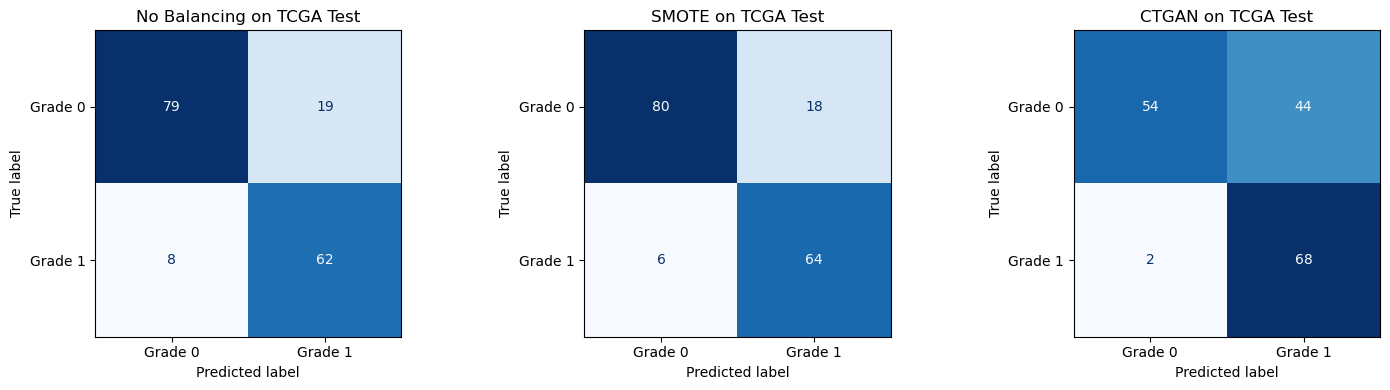

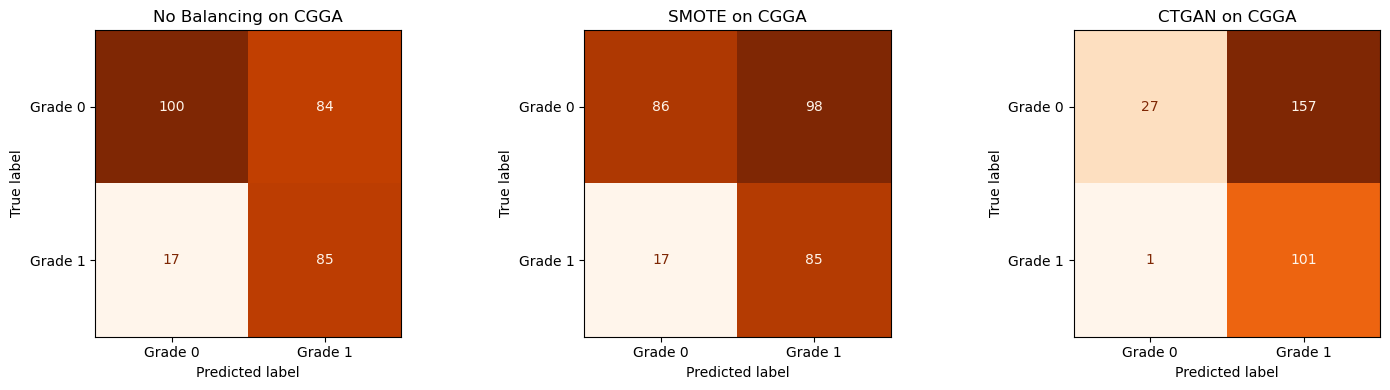


Classification Reports on TCGA Test:

No Balancing:
              precision    recall  f1-score   support

     Grade 0       0.91      0.81      0.85        98
     Grade 1       0.77      0.89      0.82        70

    accuracy                           0.84       168
   macro avg       0.84      0.85      0.84       168
weighted avg       0.85      0.84      0.84       168


SMOTE:
              precision    recall  f1-score   support

     Grade 0       0.93      0.82      0.87        98
     Grade 1       0.78      0.91      0.84        70

    accuracy                           0.86       168
   macro avg       0.86      0.87      0.86       168
weighted avg       0.87      0.86      0.86       168


CTGAN:
              precision    recall  f1-score   support

     Grade 0       0.96      0.55      0.70        98
     Grade 1       0.61      0.97      0.75        70

    accuracy                           0.73       168
   macro avg       0.79      0.76      0.72       168
weigh

In [1]:
# %% [markdown]
# # Comparison of Balancing Strategies with Independent Hyperparameter Tuning
# 
# This notebook:
# 1. Splits TCGA into train/val/test (80/16/4? Actually 80% train, 20% test, then inner 80/20 gives 64% train, 16% val, 20% test).
# 2. For each method (No Balancing, SMOTE‑NC, CTGAN):
#    - Creates a balanced training set (except for No Balancing).
#    - Performs a **separate grid search** over hyperparameters using that method’s training set and the common validation set.
#    - Trains a final model with the best hyperparameters found.
# 3. Evaluates all models on the held‑out TCGA test set and the external CGGA cohort.
# 4. Visualises results with ROC curves, calibration curves, bar charts, confusion matrices, classification reports, **and a graph structure visualisation**.

# %% [markdown]
# ## 1. Imports and Setup

# %%
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random
import copy
import networkx as nx
from itertools import product

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR

from torch_geometric.data import HeteroData
from torch_geometric.nn import GATv2Conv, Linear

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition

from imblearn.over_sampling import SMOTENC

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

# %% [markdown]
# ## 2. Load Data and Define Feature Columns

# %%
tcga_df = pd.read_csv('../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA', 
                'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 
                'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

print("Data loaded.")
print("TCGA shape:", tcga_df.shape)
print("CGGA shape:", cgga_df.shape)

# %% [markdown]
# ## 3. Stratified Splits (80/20 train/test, then inner 80/20 train/val)

# %%
# First split: 80% train, 20% test
train_df, test_df = train_test_split(
    tcga_df, 
    test_size=0.2, 
    stratify=tcga_df['Grade'], 
    random_state=42
)
print("After first split (80% train / 20% test):")
print(f"  Intermediate train size: {len(train_df)}")
print(f"  Test size: {len(test_df)}")
print("  Train class distribution:")
print(train_df['Grade'].value_counts())
print()

# Second split: further split training into final train (80%) and validation (20%)
train_df, val_df = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['Grade'], 
    random_state=42
)
print("After inner split (80% of train / 20% of train):")
print(f"  Final train size: {len(train_df)}")
print(f"  Validation size: {len(val_df)}")
print("  Final train class distribution (before balancing):")
print(train_df['Grade'].value_counts())
print()
print(f"Total patients accounted for: {len(train_df) + len(val_df) + len(test_df)} (should equal {len(tcga_df)})")

# %% [markdown]
# ## 4. Graph Construction Function

# %%
def construct_bipartite_heterograph(df):
    """
    Build a heterogeneous graph with Patient and Gene nodes.
    Patient features: Gender, Race, Age (normalized)
    Gene features: one‑hot identity
    Edges: Gene -> Patient (mutates) and reverse Patient -> Gene (mutated_by)
    """
    graph = HeteroData()
    
    # Patient features: Gender, Race, Age (normalized)
    scaler = StandardScaler()
    age_norm = scaler.fit_transform(df[['Age_at_diagnosis']])
    patient_feats = np.hstack([df[['Gender', 'Race']].values, age_norm])
    graph['Patient'].x = torch.tensor(patient_feats, dtype=torch.float)
    graph['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    
    # Gene nodes: one‑hot identity
    num_genes = len(gene_columns)
    graph['Gene'].x = torch.eye(num_genes, dtype=torch.float)
    
    # Edge lists (Gene -> Patient)
    src_genes, dst_patients = [], []
    for p_idx, (_, row) in enumerate(df.iterrows()):
        for g_idx, gene in enumerate(gene_columns):
            if int(row[gene]) == 1:
                src_genes.append(g_idx)
                dst_patients.append(p_idx)
    
    graph['Gene', 'mutates', 'Patient'].edge_index = torch.tensor([src_genes, dst_patients], dtype=torch.long)
    graph['Patient', 'mutated_by', 'Gene'].edge_index = torch.tensor([dst_patients, src_genes], dtype=torch.long)
    
    return graph

# %% [markdown]
# ## 5. Build Validation, Test, and CGGA Graphs (shared across all methods)

# %%
val_graph   = construct_bipartite_heterograph(val_df).to(device)
test_graph  = construct_bipartite_heterograph(test_df).to(device)
cgga_graph  = construct_bipartite_heterograph(cgga_df).to(device)

print("Validation, test, and CGGA graphs built.")
print(f"Validation graph: {val_graph['Patient'].x.shape[0]} patients, {val_graph['Gene'].x.shape[0]} genes, {val_graph['Gene','mutates','Patient'].edge_index.shape[1]} edges")
print(f"Test graph: {test_graph['Patient'].x.shape[0]} patients, {test_graph['Gene'].x.shape[0]} genes, {test_graph['Gene','mutates','Patient'].edge_index.shape[1]} edges")
print(f"CGGA graph: {cgga_graph['Patient'].x.shape[0]} patients, {cgga_graph['Gene'].x.shape[0]} genes, {cgga_graph['Gene','mutates','Patient'].edge_index.shape[1]} edges")

# %% [markdown]
# ## 6. Model Definition

# %%
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=8, dropout=0.5):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        
        self.patient_lin = Linear(-1, hidden_dim)
        self.gene_lin = Linear(-1, hidden_dim)
        
        self.conv_gene_to_patient = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.conv_patient_to_gene = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        
        self.patient_skip = Linear(hidden_dim, hidden_dim)
        self.gene_skip = Linear(hidden_dim, hidden_dim)
        
        self.classifier = Linear(hidden_dim, out_dim)

    def forward(self, x_dict, edge_index_dict):
        h_patient = F.relu(self.patient_lin(x_dict['Patient']))
        h_gene = F.relu(self.gene_lin(x_dict['Gene']))
        
        out_patient = self.conv_gene_to_patient((h_gene, h_patient), edge_index_dict[('Gene', 'mutates', 'Patient')])
        out_gene = self.conv_patient_to_gene((h_patient, h_gene), edge_index_dict[('Patient', 'mutated_by', 'Gene')])
        
        h_patient = self.patient_skip(h_patient) + out_patient
        h_gene = self.gene_skip(h_gene) + out_gene
        
        h_patient = F.dropout(F.leaky_relu(h_patient, 0.2), self.dropout, training=self.training)
        h_gene = F.dropout(F.leaky_relu(h_gene, 0.2), self.dropout, training=self.training)
        
        return self.classifier(h_patient)

# %% [markdown]
# ## 7. Loss Function and Class Weights

# %%
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Class weights from original imbalanced training set (for loss)
original_counts = train_df['Grade'].value_counts()
majority = original_counts.idxmax()
minority = original_counts.idxmin()
penalty = original_counts[majority] / original_counts[minority]
class_weights = torch.tensor([1.0, penalty], dtype=torch.float).to(device)

criterion = FocalLoss(alpha=1, gamma=2, weight=class_weights)

# %% [markdown]
# ## 8. Training Function with Grid Search Support

# %%
def train_and_evaluate(train_graph, val_graph, params, max_epochs=200, patience=20):
    """
    Train a model with given hyperparameters and return best validation AUC, model state, and validation history.
    """
    model = HeteroGATv2(
        hidden_dim=params['hidden_dim'],
        out_dim=2,
        num_heads=params['num_heads'],
        dropout=params['dropout']
    ).to(device)

    with torch.no_grad():
        _ = model(train_graph.x_dict, train_graph.edge_index_dict)

    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = StepLR(optimizer, step_size=50, gamma=0.5)

    best_val_auc = 0
    patience_counter = 0
    best_state = None
    val_aucs = []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        out = model(train_graph.x_dict, train_graph.edge_index_dict)
        loss = criterion(out, train_graph['Patient'].y)
        loss.backward()
        optimizer.step()
        scheduler.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = model(val_graph.x_dict, val_graph.edge_index_dict)
            val_probs = F.softmax(val_out, dim=1)[:, 1].cpu().numpy()
            val_labels = val_graph['Patient'].y.cpu().numpy()
            val_auc = roc_auc_score(val_labels, val_probs)
            val_aucs.append(val_auc)

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_val_auc, best_state, val_aucs

# %% [markdown]
# ## 9. Grid Search Function

# %%
def grid_search(train_graph, val_graph, param_grid):
    """
    Perform grid search over hyperparameters and return best params, best model state, and validation history.
    """
    keys = param_grid.keys()
    values = param_grid.values()
    combinations = list(product(*values))
    
    best_score = 0
    best_params = None
    best_state = None
    best_val_aucs = None
    
    for i, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        print(f"  Trial {i+1}/{len(combinations)}: {params}")
        val_auc, state, val_aucs = train_and_evaluate(train_graph, val_graph, params)
        print(f"    Validation AUC: {val_auc:.4f}")
        
        if val_auc > best_score:
            best_score = val_auc
            best_params = params
            best_state = state
            best_val_aucs = val_aucs
    
    return best_params, best_state, best_val_aucs

# %% [markdown]
# ## 10. Define Hyperparameter Grid

# %%
param_grid = {
    'hidden_dim': [16, 32, 64],
    'num_heads': [4, 8],
    'dropout': [0.3, 0.5, 0.7],
    'lr': [0.001, 0.005],
    'weight_decay': [1e-4, 5e-4]
}

# %% [markdown]
# ## 11. No Balancing Pipeline

# %%
print("\n" + "="*50)
print("NO BALANCING")
print("="*50)

# Build training graph (imbalanced)
train_no_bal_graph = construct_bipartite_heterograph(train_df).to(device)

# Grid search
print("Performing grid search for No Balancing...")
best_params_no_bal, best_state_no_bal, val_aucs_no_bal = grid_search(train_no_bal_graph, val_graph, param_grid)

print("\nBest hyperparameters for No Balancing:")
for k, v in best_params_no_bal.items():
    print(f"  {k}: {v}")

# Train final model with best params (just loading the state from grid search)
model_no_bal = HeteroGATv2(
    hidden_dim=best_params_no_bal['hidden_dim'],
    out_dim=2,
    num_heads=best_params_no_bal['num_heads'],
    dropout=best_params_no_bal['dropout']
).to(device)
model_no_bal.load_state_dict(best_state_no_bal)

# %% [markdown]
# ## 12. SMOTE Pipeline

# %%
print("\n" + "="*50)
print("SMOTE")
print("="*50)

# Apply SMOTENC to training set
feature_columns = gene_columns + ['Gender', 'Race', 'Age_at_diagnosis']
categorical_indices = [i for i, col in enumerate(feature_columns) 
                       if col in gene_columns or col in ['Gender', 'Race']]

smote = SMOTENC(categorical_features=categorical_indices, random_state=42, k_neighbors=3)
X_res, y_res = smote.fit_resample(train_df[feature_columns], train_df['Grade'])

train_smote_df = pd.DataFrame(X_res, columns=feature_columns)
train_smote_df['Grade'] = y_res
for col in gene_columns:
    train_smote_df[col] = train_smote_df[col].round().astype(int)

print("SMOTE-balanced training set created.")
print(train_smote_df['Grade'].value_counts())

# Build graph
train_smote_graph = construct_bipartite_heterograph(train_smote_df).to(device)

# Grid search
print("Performing grid search for SMOTE...")
best_params_smote, best_state_smote, val_aucs_smote = grid_search(train_smote_graph, val_graph, param_grid)

print("\nBest hyperparameters for SMOTE:")
for k, v in best_params_smote.items():
    print(f"  {k}: {v}")

# Train final model
model_smote = HeteroGATv2(
    hidden_dim=best_params_smote['hidden_dim'],
    out_dim=2,
    num_heads=best_params_smote['num_heads'],
    dropout=best_params_smote['dropout']
).to(device)
model_smote.load_state_dict(best_state_smote)

# %% [markdown]
# ## 13. CTGAN Pipeline

# %%
print("\n" + "="*50)
print("CTGAN")
print("="*50)

# Apply CTGAN to training set
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    metadata.update_column(column_name=col, sdtype='categorical')

class_counts = train_df['Grade'].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
samples_needed = class_counts[majority_class] - class_counts[minority_class]

print(f"Generating {samples_needed} synthetic minority samples...")
synthesizer = CTGANSynthesizer(metadata, epochs=150, batch_size=50, verbose=False, cuda=True)
synthesizer.fit(train_df)

condition = Condition(num_rows=samples_needed, column_values={'Grade': minority_class})
synthetic_samples = synthesizer.sample_from_conditions(conditions=[condition])

train_ctgan_df = pd.concat([train_df, synthetic_samples], ignore_index=True)
print("CTGAN-balanced training set created.")
print(train_ctgan_df['Grade'].value_counts())

# Build graph
train_ctgan_graph = construct_bipartite_heterograph(train_ctgan_df).to(device)

# Grid search
print("Performing grid search for CTGAN...")
best_params_ctgan, best_state_ctgan, val_aucs_ctgan = grid_search(train_ctgan_graph, val_graph, param_grid)

print("\nBest hyperparameters for CTGAN:")
for k, v in best_params_ctgan.items():
    print(f"  {k}: {v}")

# Train final model
model_ctgan = HeteroGATv2(
    hidden_dim=best_params_ctgan['hidden_dim'],
    out_dim=2,
    num_heads=best_params_ctgan['num_heads'],
    dropout=best_params_ctgan['dropout']
).to(device)
model_ctgan.load_state_dict(best_state_ctgan)

# %% [markdown]
# ## 14. Graph Construction Visualisation
# 
# Now that all graphs are built, let's visualise a small subset of one of them (the CTGAN‑balanced training graph) to understand the bipartite structure.

# %%
def visualize_graph_subset(graph, num_patients=10, title="Graph Subset"):
    """
    Visualise a subset of the bipartite graph.
    
    Args:
        graph: HeteroData object containing 'Patient' and 'Gene' nodes.
        num_patients: Number of patient nodes to include (starting from first patients).
        title: Title for the plot.
    """
    # Get edge index for Gene -> Patient edges
    edge_index = graph['Gene', 'mutates', 'Patient'].edge_index.cpu()
    
    # Select a subset of patients (the first 'num_patients')
    unique_patients = torch.unique(edge_index[1])[:num_patients]
    
    # Filter edges that involve these patients
    mask = torch.isin(edge_index[1], unique_patients)
    sub_edge = edge_index[:, mask]
    
    # Get the genes that appear in these edges
    genes_in_sub = torch.unique(sub_edge[0]).tolist()
    
    # Create a NetworkX graph
    G = nx.Graph()
    
    # Add patient nodes with grade information
    patient_grades = graph['Patient'].y.cpu().numpy()
    for p in unique_patients.tolist():
        grade = patient_grades[p]
        color = 'lightblue' if grade == 0 else 'salmon'
        G.add_node(f"P{p}", bipartite=0, color=color, grade=grade)
    
    # Add gene nodes
    for g in genes_in_sub:
        G.add_node(f"G{g}", bipartite=1, color='lightgreen')
    
    # Add edges
    for i in range(sub_edge.shape[1]):
        g = f"G{sub_edge[0,i].item()}"
        p = f"P{sub_edge[1,i].item()}"
        G.add_edge(g, p)
    
    # Draw the graph
    plt.figure(figsize=(12, 8))
    pos = nx.bipartite_layout(G, [n for n in G.nodes if n.startswith('P')])
    
    # Node colors
    node_colors = [G.nodes[n]['color'] for n in G.nodes]
    
    nx.draw(G, pos, with_labels=True, node_color=node_colors,
            node_size=500, font_size=8, edge_color='gray', alpha=0.7)
    
    plt.title(f"{title} ({len(unique_patients)} patients, {len(genes_in_sub)} genes)")
    plt.show()
    
    # Print statistics
    print(f"Graph subset contains:")
    print(f"  - {len(unique_patients)} patient nodes")
    print(f"  - {len(genes_in_sub)} gene nodes")
    print(f"  - {sub_edge.shape[1]} mutation edges")
    print(f"Patient grades in subset: {[patient_grades[p] for p in unique_patients.tolist()]}")

# Visualise a subset of the CTGAN‑balanced training graph
print("\nVisualising a subset of the CTGAN‑balanced training graph:")
visualize_graph_subset(train_ctgan_graph, num_patients=8, title="CTGAN Training Graph Subset")

# You can also uncomment the following lines to visualise other graphs:
# visualize_graph_subset(train_no_bal_graph, num_patients=8, title="No Balancing Training Graph Subset")
# visualize_graph_subset(train_smote_graph, num_patients=8, title="SMOTE Training Graph Subset")
# visualize_graph_subset(val_graph, num_patients=8, title="Validation Graph Subset")
# visualize_graph_subset(test_graph, num_patients=8, title="Test Graph Subset")
# visualize_graph_subset(cgga_graph, num_patients=8, title="CGGA Graph Subset")

# %% [markdown]
# ## 15. Evaluation Function

# %%
def evaluate_model(model, graph):
    model.eval()
    with torch.no_grad():
        out = model(graph.x_dict, graph.edge_index_dict)
        probs = F.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
        
        acc = accuracy_score(labels, preds)
        auc = roc_auc_score(labels, probs[:, 1])
        precision = precision_score(labels, preds, average='binary')
        recall = recall_score(labels, preds, average='binary')
        f1 = f1_score(labels, preds, average='binary')
        
        report = classification_report(labels, preds, output_dict=True, target_names=['Grade 0', 'Grade 1'])
        
    return {
        'accuracy': acc,
        'auc': auc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'report': report,
        'probs': probs,
        'preds': preds,
        'labels': labels
    }

# %% [markdown]
# ## 16. Evaluate All Models

# %%
results = []
models_info = [
    ('No Balancing', model_no_bal, val_aucs_no_bal),
    ('SMOTE', model_smote, val_aucs_smote),
    ('CTGAN', model_ctgan, val_aucs_ctgan)
]

# Store validation histories for later plotting
val_histories = {}

for name, model, val_aucs in models_info:
    val_histories[name] = val_aucs
    # TCGA test
    res_test = evaluate_model(model, test_graph)
    # CGGA
    res_cgga = evaluate_model(model, cgga_graph)
    
    results.append({'Method': name, 'Dataset': 'TCGA Test', 
                    'accuracy': res_test['accuracy'], 'auc': res_test['auc'],
                    'precision': res_test['precision'], 'recall': res_test['recall'], 'f1': res_test['f1']})
    results.append({'Method': name, 'Dataset': 'CGGA', 
                    'accuracy': res_cgga['accuracy'], 'auc': res_cgga['auc'],
                    'precision': res_cgga['precision'], 'recall': res_cgga['recall'], 'f1': res_cgga['f1']})
    
    # Store predictions for later plotting
    if name == 'No Balancing':
        probs_test_nb, probs_cgga_nb = res_test['probs'][:,1], res_cgga['probs'][:,1]
        labels_test_nb, labels_cgga_nb = res_test['labels'], res_cgga['labels']
        preds_test_nb, preds_cgga_nb = res_test['preds'], res_cgga['preds']
    elif name == 'SMOTE':
        probs_test_sm, probs_cgga_sm = res_test['probs'][:,1], res_cgga['probs'][:,1]
        labels_test_sm, labels_cgga_sm = res_test['labels'], res_cgga['labels']
        preds_test_sm, preds_cgga_sm = res_test['preds'], res_cgga['preds']
    else:
        probs_test_ct, probs_cgga_ct = res_test['probs'][:,1], res_cgga['probs'][:,1]
        labels_test_ct, labels_cgga_ct = res_test['labels'], res_cgga['labels']
        preds_test_ct, preds_cgga_ct = res_test['preds'], res_cgga['preds']

results_df = pd.DataFrame(results)
print("\n=== Summary Table ===")
print(results_df.to_string(index=False))

# %% [markdown]
# ## 17. Visualizations

# %%
# 17.1 Validation AUC curves during training
plt.figure(figsize=(10,5))
for name, aucs in val_histories.items():
    plt.plot(aucs, label=name)
plt.xlabel('Epoch')
plt.ylabel('Validation AUC')
plt.title('Validation AUC during Training (Best Models)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 17.2 ROC curves on TCGA Test
plt.figure(figsize=(8,6))
fpr_nb, tpr_nb, _ = roc_curve(labels_test_nb, probs_test_nb)
fpr_sm, tpr_sm, _ = roc_curve(labels_test_sm, probs_test_sm)
fpr_ct, tpr_ct, _ = roc_curve(labels_test_ct, probs_test_ct)

auc_nb_test = results_df[(results_df.Method=="No Balancing") & (results_df.Dataset=="TCGA Test")]['auc'].values[0]
auc_sm_test = results_df[(results_df.Method=="SMOTE") & (results_df.Dataset=="TCGA Test")]['auc'].values[0]
auc_ct_test = results_df[(results_df.Method=="CTGAN") & (results_df.Dataset=="TCGA Test")]['auc'].values[0]

plt.plot(fpr_nb, tpr_nb, label=f'No Balancing (AUC = {auc_nb_test:.3f})')
plt.plot(fpr_sm, tpr_sm, label=f'SMOTE (AUC = {auc_sm_test:.3f})')
plt.plot(fpr_ct, tpr_ct, label=f'CTGAN (AUC = {auc_ct_test:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on TCGA Test')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 17.3 ROC curves on CGGA
plt.figure(figsize=(8,6))
fpr_nb, tpr_nb, _ = roc_curve(labels_cgga_nb, probs_cgga_nb)
fpr_sm, tpr_sm, _ = roc_curve(labels_cgga_sm, probs_cgga_sm)
fpr_ct, tpr_ct, _ = roc_curve(labels_cgga_ct, probs_cgga_ct)

auc_nb_cgga = results_df[(results_df.Method=="No Balancing") & (results_df.Dataset=="CGGA")]['auc'].values[0]
auc_sm_cgga = results_df[(results_df.Method=="SMOTE") & (results_df.Dataset=="CGGA")]['auc'].values[0]
auc_ct_cgga = results_df[(results_df.Method=="CTGAN") & (results_df.Dataset=="CGGA")]['auc'].values[0]

plt.plot(fpr_nb, tpr_nb, label=f'No Balancing (AUC = {auc_nb_cgga:.3f})')
plt.plot(fpr_sm, tpr_sm, label=f'SMOTE (AUC = {auc_sm_cgga:.3f})')
plt.plot(fpr_ct, tpr_ct, label=f'CTGAN (AUC = {auc_ct_cgga:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on CGGA')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 17.4 Calibration curves on TCGA Test
plt.figure(figsize=(8,6))
for probs, label in [(probs_test_nb, 'No Balancing'),
                      (probs_test_sm, 'SMOTE'),
                      (probs_test_ct, 'CTGAN')]:
    fraction, mean_pred = calibration_curve(labels_test_nb, probs, n_bins=10)
    plt.plot(mean_pred, fraction, marker='o', label=label)
plt.plot([0,1], [0,1], 'k--', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curves on TCGA Test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 17.5 Calibration curves on CGGA
plt.figure(figsize=(8,6))
for probs, label in [(probs_cgga_nb, 'No Balancing'),
                      (probs_cgga_sm, 'SMOTE'),
                      (probs_cgga_ct, 'CTGAN')]:
    fraction, mean_pred = calibration_curve(labels_cgga_nb, probs, n_bins=10)
    plt.plot(mean_pred, fraction, marker='o', label=label)
plt.plot([0,1], [0,1], 'k--', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curves on CGGA')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 17.6 Bar charts for all metrics
metrics_display = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1']
metrics_cols = ['accuracy', 'auc', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_display))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15,5))

for ax, dataset in zip(axes, ['TCGA Test', 'CGGA']):
    subset = results_df[results_df.Dataset == dataset]
    nb_vals = [subset[subset.Method == 'No Balancing'][col].values[0] for col in metrics_cols]
    sm_vals = [subset[subset.Method == 'SMOTE'][col].values[0] for col in metrics_cols]
    ct_vals = [subset[subset.Method == 'CTGAN'][col].values[0] for col in metrics_cols]
    
    ax.bar(x - width, nb_vals, width, label='No Balancing', color='skyblue')
    ax.bar(x, sm_vals, width, label='SMOTE', color='lightgreen')
    ax.bar(x + width, ct_vals, width, label='CTGAN', color='salmon')
    
    ax.set_xlabel('Metric')
    ax.set_ylabel('Score')
    ax.set_title(f'{dataset} Performance')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_display)
    ax.set_ylim(0,1)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    for i, (nb, sm, ct) in enumerate(zip(nb_vals, sm_vals, ct_vals)):
        ax.text(i - width, nb + 0.02, f'{nb:.2f}', ha='center', va='bottom', fontsize=8)
        ax.text(i, sm + 0.02, f'{sm:.2f}', ha='center', va='bottom', fontsize=8)
        ax.text(i + width, ct + 0.02, f'{ct:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# 17.7 Confusion Matrices for TCGA Test
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, preds, labels) in zip(axes, 
                                      [('No Balancing', preds_test_nb, labels_test_nb),
                                       ('SMOTE', preds_test_sm, labels_test_sm),
                                       ('CTGAN', preds_test_ct, labels_test_ct)]):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Grade 0', 'Grade 1'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} on TCGA Test')
plt.tight_layout()
plt.show()

# 17.8 Confusion Matrices for CGGA
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, preds, labels) in zip(axes, 
                                      [('No Balancing', preds_cgga_nb, labels_cgga_nb),
                                       ('SMOTE', preds_cgga_sm, labels_cgga_sm),
                                       ('CTGAN', preds_cgga_ct, labels_cgga_ct)]):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Grade 0', 'Grade 1'])
    disp.plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(f'{name} on CGGA')
plt.tight_layout()
plt.show()

# 17.9 Print classification reports
print("\nClassification Reports on TCGA Test:")
for name, preds, labels in [('No Balancing', preds_test_nb, labels_test_nb),
                             ('SMOTE', preds_test_sm, labels_test_sm),
                             ('CTGAN', preds_test_ct, labels_test_ct)]:
    print(f"\n{name}:")
    print(classification_report(labels, preds, target_names=['Grade 0', 'Grade 1']))

print("\nClassification Reports on CGGA:")
for name, preds, labels in [('No Balancing', preds_cgga_nb, labels_cgga_nb),
                             ('SMOTE', preds_cgga_sm, labels_cgga_sm),
                             ('CTGAN', preds_cgga_ct, labels_cgga_ct)]:
    print(f"\n{name}:")
    print(classification_report(labels, preds, target_names=['Grade 0', 'Grade 1']))

# %% [markdown]
# ## 18. (Optional) Save Models

# %%
# torch.save(model_no_bal.state_dict(), 'model_no_bal.pth')
# torch.save(model_smote.state_dict(), 'model_smote.pth')
# torch.save(model_ctgan.state_dict(), 'model_ctgan.pth')
# print("Models saved.")